In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

df = sns.load_dataset("taxis")
df.head()

,pickup,dropoff,passengers,distance,fare,tip,tolls,total,color,payment,pickup_zone,dropoff_zone,pickup_borough,dropoff_borough
0,2019-03-23 20:21:09,2019-03-23 20:27:24,1,1.60,7.0,2.15,0.0,12.95,yellow,credit card,Lenox Hill West,UN/Turtle Bay South,Manhattan,Manhattan
1,2019-03-04 16:11:55,2019-03-04 16:19:00,1,0.79,5.0,0.00,0.0,9.30,yellow,cash,Upper West Side South,Upper West Side South,Manhattan,Manhattan
2,2019-03-27 17:53:01,2019-03-27 18:00:25,1,1.37,7.5,2.36,0.0,14.16,yellow,credit card,Alphabet City,West Village,Manhattan,Manhattan
3,2019-03-10 01:23:59,2019-03-10 01:49:51,1,7.70,27.0,6.15,0.0,36.95,yellow,credit card,Hudson Sq,Yorkville West,Manhattan,Manhattan
4,2019-03-30 13:27:42,2019-03-30 13:37:14,3,2.16,9.0,1.10,0.0,13.40,yellow,credit card,Midtown East,Yorkville West,Manhattan,Manhattan


In [2]:
print(df.isnull().sum())

# Categorical -> mode
for col in ["payment", "pickup_zone", "dropoff_zone",
            "pickup_borough", "dropoff_borough"]:
    df[col] = df[col].fillna(df[col].mode()[0])

# Numerical -> median (only if any are missing)
for col in df.select_dtypes("number").columns:
    df[col] = df[col].fillna(df[col].median())

# Critical columns that can't be reasonably imputed -> drop rows
df = df.dropna(subset=["pickup", "dropoff", "fare", "distance"])

print(df.isnull().sum().sum(), "missing values left")

pickup              0
dropoff             0
passengers          0
distance            0
fare                0
tip                 0
tolls               0
total               0
color               0
payment            44
pickup_zone        26
dropoff_zone       45
pickup_borough     26
dropoff_borough    45
dtype: int64
0 missing values left


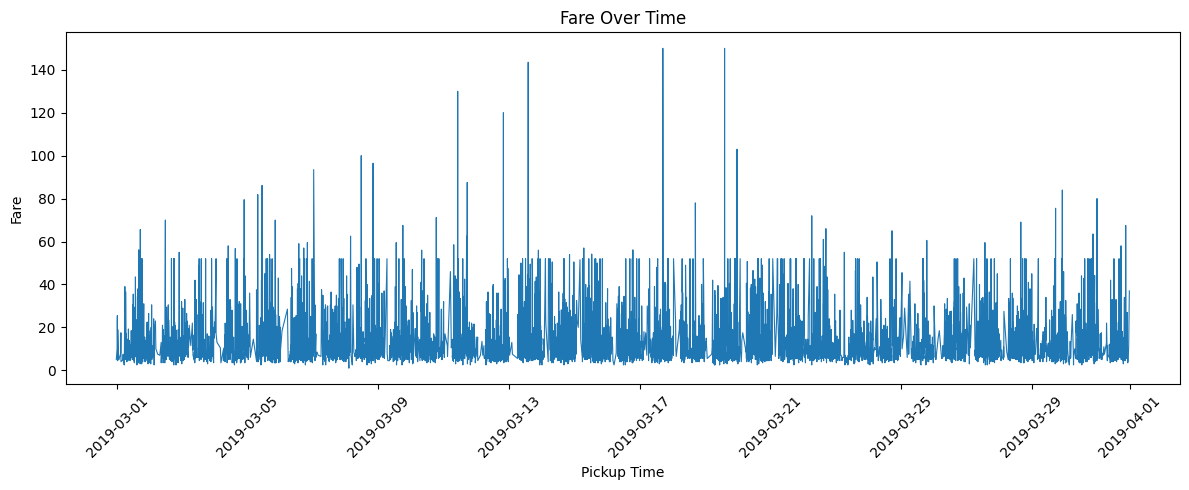

In [4]:
# Line chart: fare over time
df["pickup"] = pd.to_datetime(df["pickup"])
d = df.sort_values("pickup")
plt.figure(figsize=(12, 5))
plt.plot(d["pickup"], d["fare"], linewidth=0.8)
plt.title("Fare Over Time"); plt.xlabel("Pickup Time"); plt.ylabel("Fare")
plt.xticks(rotation=45); plt.tight_layout(); plt.show()


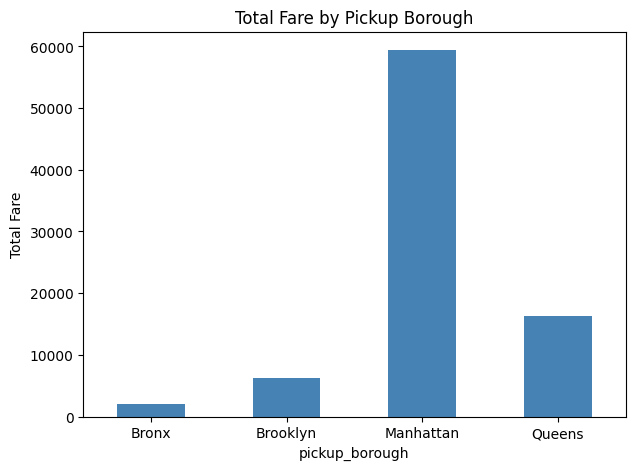

In [5]:
# Bar chart: total fare per pickup borough
df.groupby("pickup_borough")["fare"].sum().plot(kind="bar", color="steelblue", figsize=(7, 5))
plt.title("Total Fare by Pickup Borough"); plt.ylabel("Total Fare")
plt.xticks(rotation=0); plt.show()

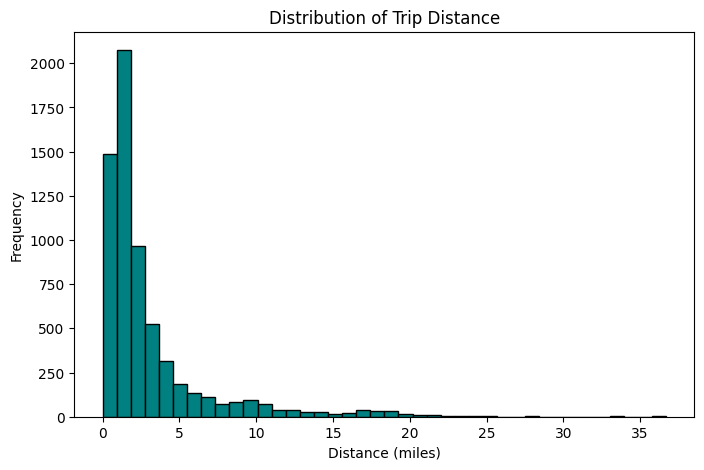

In [9]:
# Histogram: distance
plt.figure(figsize=(8, 5))
plt.hist(df["distance"], bins=40, color="teal", edgecolor="black")
plt.title("Distribution of Trip Distance"); plt.xlabel("Distance (miles)"); plt.ylabel("Frequency")
plt.show()

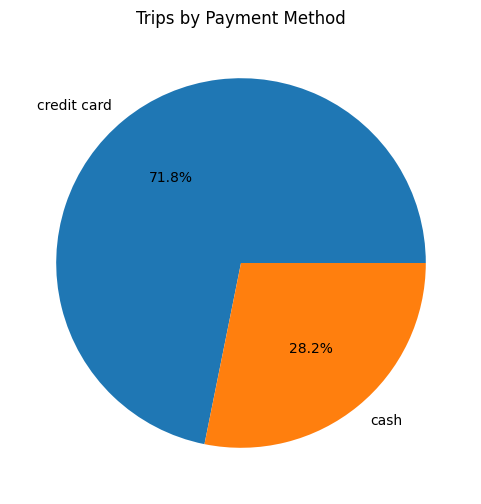

In [6]:
# Pie chart: trips by payment method
df["payment"].value_counts().plot(kind="pie", autopct="%1.1f%%", figsize=(6, 6))
plt.title("Trips by Payment Method"); plt.ylabel(""); plt.show()

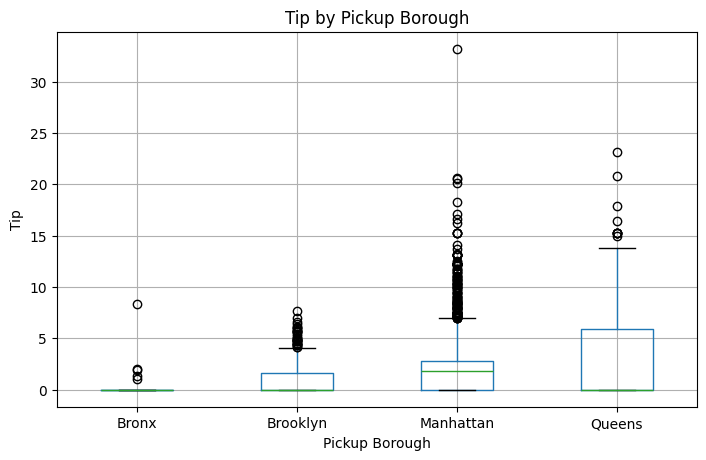

In [8]:
# Box plot: tip by pickup borough
df.boxplot(column="tip", by="pickup_borough", figsize=(8, 5))
plt.title("Tip by Pickup Borough"); plt.suptitle("")
plt.xlabel("Pickup Borough"); plt.ylabel("Tip"); plt.show()

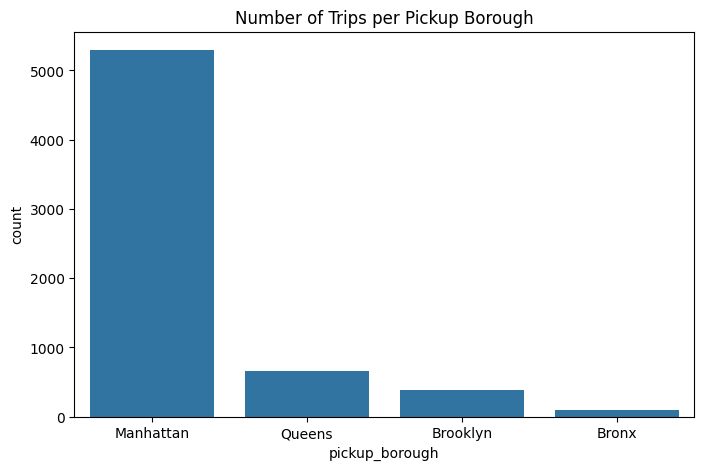

In [10]:
# Count plot
plt.figure(figsize=(8, 5))
sns.countplot(data=df, x="pickup_borough", order=df["pickup_borough"].value_counts().index)
plt.title("Number of Trips per Pickup Borough"); plt.show()

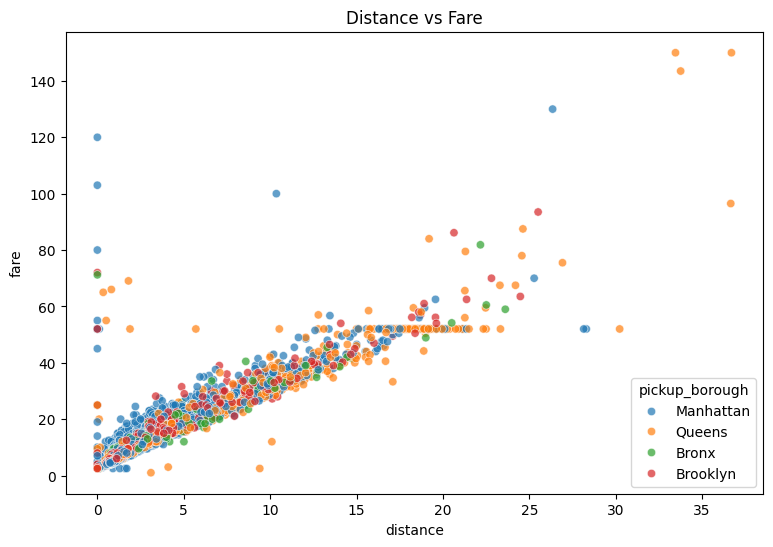

In [11]:
# Scatter plot
plt.figure(figsize=(9, 6))
sns.scatterplot(data=df, x="distance", y="fare", hue="pickup_borough", alpha=0.7)
plt.title("Distance vs Fare"); plt.show()

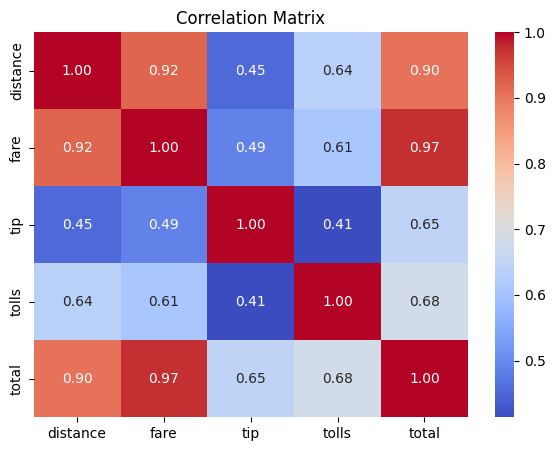

In [12]:
# Heatmap
plt.figure(figsize=(7, 5))
sns.heatmap(df[["distance", "fare", "tip", "tolls", "total"]].corr(),
            annot=True, cmap="coolwarm", fmt=".2f")
plt.title("Correlation Matrix"); plt.show()

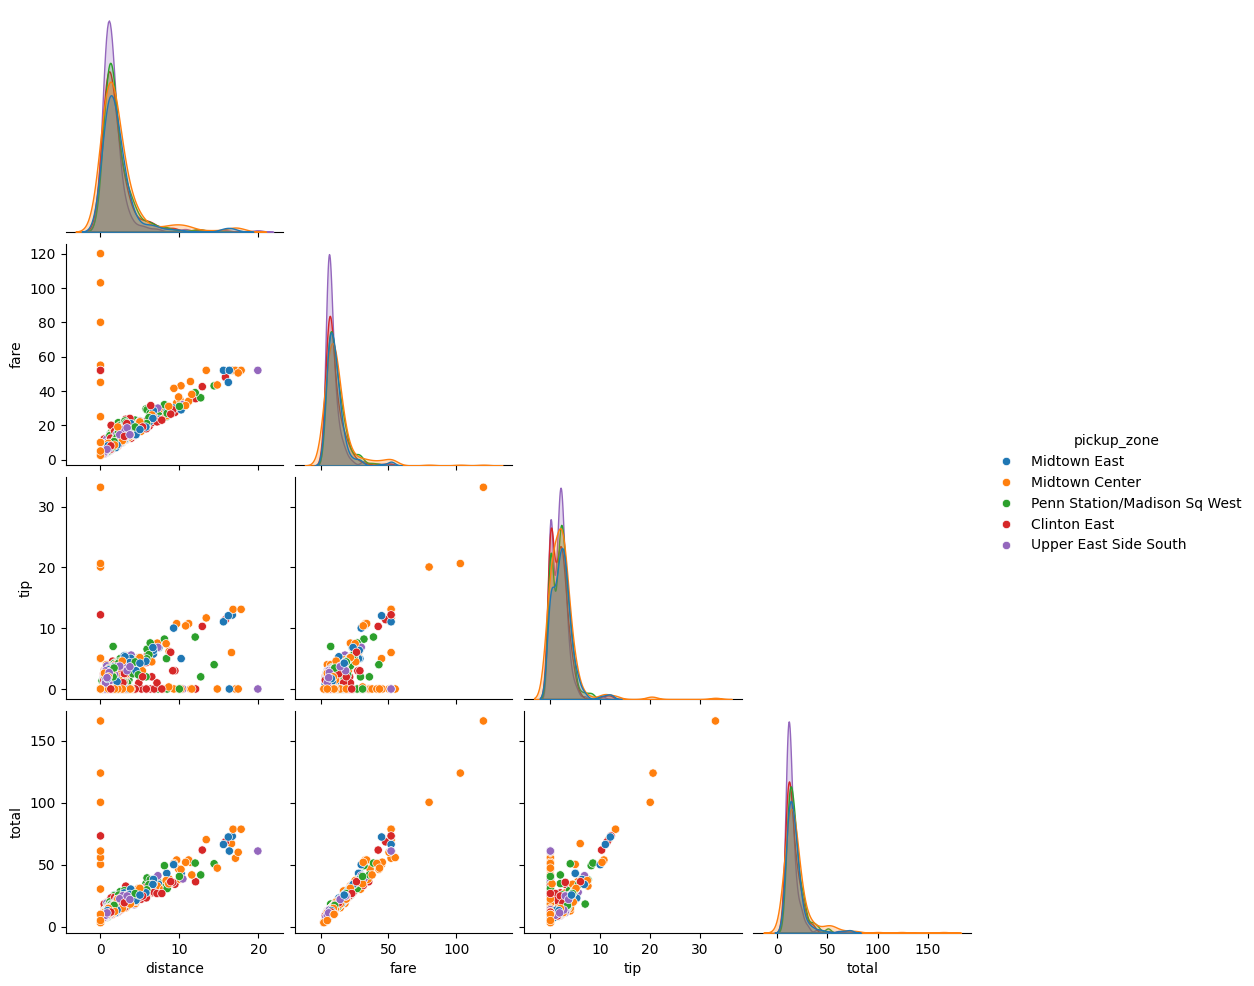

In [13]:
# Pair plot (pickup_zone has ~190 zones, so colour only the top 5)
top_zones = df["pickup_zone"].value_counts().head(5).index
sub = df[df["pickup_zone"].isin(top_zones)]
sns.pairplot(sub, vars=["distance", "fare", "tip", "total"], hue="pickup_zone", corner=True)
plt.show()

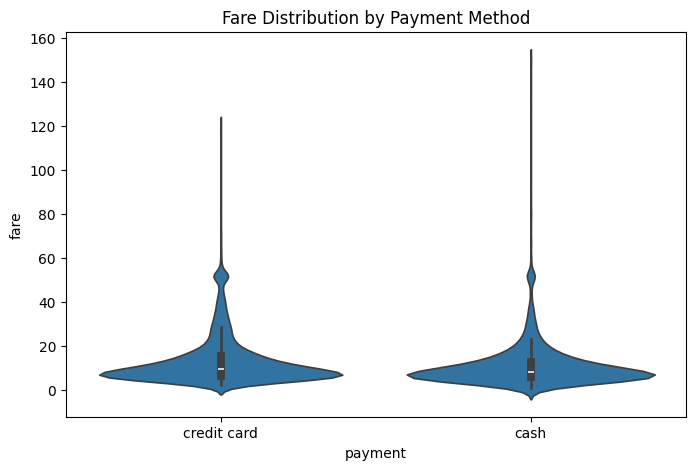

In [14]:
# Violin plot
plt.figure(figsize=(8, 5))
sns.violinplot(data=df, x="payment", y="fare")
plt.title("Fare Distribution by Payment Method"); plt.show()